In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [11]:

# Load datasets
weather = pd.read_csv("../data/raw/weather_data.csv")
airports = pd.read_csv("../data/raw/global_airports.csv")

print("=== Weather Dataset ===")
print(f"Shape: {weather.shape}")
print(weather.head())

print("\n=== Airports Dataset ===")
print(f"Shape: {airports.shape}")
print(airports.head())

=== Weather Dataset ===
Shape: (1000000, 6)
       Location            Date_Time  Temperature_C  Humidity_pct  \
0     San Diego  2024-01-14 21:12:46      10.683001     41.195754   
1     San Diego  2024-05-17 15:22:10       8.734140     58.319107   
2     San Diego  2024-05-11 09:30:59      11.632436     38.820175   
3  Philadelphia  2024-02-26 17:32:39      -8.628976     54.074474   
4   San Antonio  2024-04-29 13:23:51      39.808213     72.899908   

   Precipitation_mm  Wind_Speed_kmh  
0          4.020119        8.233540  
1          9.111623       27.715161  
2          4.607511       28.732951  
3          3.183720       26.367303  
4          9.598282       29.898622  

=== Airports Dataset ===
Shape: (6393, 13)
            AirportName IATA  ICAO             TimeZone            City_Name  \
0      Pilanesberg Intl  NTY  FAPN  Africa/Johannesburg             Sun City   
1           Clovis Muni  CVN  KCVN       America/Denver   Clovis, New Mexico   
2            Cannon Afb  CVS 

In [12]:
print("=== Weather Columns ===")
print(weather.columns.tolist())
print(f"\nUnique Locations in Weather: {weather['Location'].nunique()}")
print(weather['Location'].unique()[:20])

print("\n=== Airports Columns ===")
print(airports.columns.tolist())

print("\n=== Missing Values - Weather ===")
print(weather.isnull().sum())

print("\n=== Missing Values - Airports ===")
print(airports.isnull().sum())

=== Weather Columns ===
['Location', 'Date_Time', 'Temperature_C', 'Humidity_pct', 'Precipitation_mm', 'Wind_Speed_kmh']

Unique Locations in Weather: 10
<ArrowStringArray>
[   'San Diego', 'Philadelphia',  'San Antonio',     'San Jose',
     'New York',      'Houston',       'Dallas',      'Chicago',
  'Los Angeles',      'Phoenix']
Length: 10, dtype: str

=== Airports Columns ===
['AirportName', 'IATA', 'ICAO', 'TimeZone', 'City_Name', 'City_IATA', 'UTC_Offset_Hours', 'UTC_Offset_Seconds', 'Country_CodeA2', 'Country_CodeA3', 'Country_Name', 'GeoPointLat', 'GeoPointLong']

=== Missing Values - Weather ===
Location            0
Date_Time           0
Temperature_C       0
Humidity_pct        0
Precipitation_mm    0
Wind_Speed_kmh      0
dtype: int64

=== Missing Values - Airports ===
AirportName              0
IATA                    20
ICAO                  1302
TimeZone                88
City_Name                0
City_IATA               62
UTC_Offset_Hours        88
UTC_Offset_Second

In [13]:
# Check how City_Name looks in airports for our 10 cities
city_mapping = {
    'San Diego': 'San Diego',
    'Philadelphia': 'Philadelphia',
    'San Antonio': 'San Antonio',
    'San Jose': 'San Jose',
    'New York': 'New York',
    'Houston': 'Houston',
    'Dallas': 'Dallas',
    'Chicago': 'Chicago',
    'Los Angeles': 'Los Angeles',
    'Phoenix': 'Phoenix'
}

# Find matching airports
for city in city_mapping:
    matches = airports[airports['City_Name'].str.contains(city, case=False, na=False)][['AirportName', 'IATA', 'City_Name']]
    print(f"\n{city}:")
    print(matches.to_string())


San Diego:
                        AirportName IATA              City_Name
1133  Brown Field Municipal Airport  SDM  San Diego, California
1134                      Gillespie  SEE  San Diego, California
1135                   Miramar Mcas  NKX  San Diego, California
1136               Montgomery Field  MYF  San Diego, California
1137               North Island Nas  NZY  San Diego, California
1138      McClellan-Palomar Airport  CLD  San Diego, California
1139                 San Diego Intl  SAN  San Diego, California

Philadelphia:
                       AirportName IATA                   City_Name
1582    Harry Clever Field Airport  PHD      New Philadelphia, Ohio
5866                Trenton Mercer  TTN  Philadelphia, Pennsylvania
5867          Mustin alf            MUV  Philadelphia, Pennsylvania
5868        Northeast Philadelphia  PNE  Philadelphia, Pennsylvania
5869          Spb                   PSQ  Philadelphia, Pennsylvania
5870                   Wings Field  BBX  Philadelphia

In [14]:
# Map each city to its main commercial airport IATA codes
city_to_iata = {
    'San Diego':    ['SAN'],
    'Philadelphia': ['PHL'],
    'San Antonio':  ['SAT'],
    'San Jose':     ['SJC'],
    'New York':     ['JFK', 'LGA', 'EWR'],
    'Houston':      ['IAH', 'HOU'],
    'Dallas':       ['DFW', 'DAL'],
    'Chicago':      ['ORD', 'MDW'],
    'Los Angeles':  ['LAX'],
    'Phoenix':      ['PHX']
}

# Expand into a flat DataFrame: one row per IATA code
mapping_rows = []
for city, iata_list in city_to_iata.items():
    for iata in iata_list:
        mapping_rows.append({'Location': city, 'iata': iata})

city_iata_df = pd.DataFrame(mapping_rows)
print(city_iata_df)
print(f"\nTotal airports mapped: {len(city_iata_df)}")

        Location iata
0      San Diego  SAN
1   Philadelphia  PHL
2    San Antonio  SAT
3       San Jose  SJC
4       New York  JFK
5       New York  LGA
6       New York  EWR
7        Houston  IAH
8        Houston  HOU
9         Dallas  DFW
10        Dallas  DAL
11       Chicago  ORD
12       Chicago  MDW
13   Los Angeles  LAX
14       Phoenix  PHX

Total airports mapped: 15


In [15]:
# Merge weather with city-to-IATA mapping
weather = weather.merge(city_iata_df, on='Location', how='left')

# Extract date and hour from Date_Time
weather['date'] = pd.to_datetime(weather['Date_Time']).dt.date
weather['hour'] = pd.to_datetime(weather['Date_Time']).dt.hour
# Rename columns to match project schema
weather.rename(columns={
    'Precipitation_mm': 'precipitation',
    'Temperature_C':    'temperature_c',
    'Humidity_pct':     'humidity_pct',
    'Wind_Speed_kmh':   'wind_speed_kmh'
}, inplace=True)

# Keep only needed columns
weather = weather[['iata', 'date', 'hour', 'precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']]

print(weather.head())
print(f"\nShape: {weather.shape}")
print(f"\nMissing values:\n{weather.isnull().sum()}")

  iata        date  hour  precipitation  temperature_c  humidity_pct  \
0  SAN  2024-01-14    21       4.020119      10.683001     41.195754   
1  SAN  2024-05-17    15       9.111623       8.734140     58.319107   
2  SAN  2024-05-11     9       4.607511      11.632436     38.820175   
3  PHL  2024-02-26    17       3.183720      -8.628976     54.074474   
4  SAT  2024-04-29    13       9.598282      39.808213     72.899908   

   wind_speed_kmh  
0        8.233540  
1       27.715161  
2       28.732951  
3       26.367303  
4       29.898622  

Shape: (1500120, 7)

Missing values:
iata              0
date              0
hour              0
precipitation     0
temperature_c     0
humidity_pct      0
wind_speed_kmh    0
dtype: int64


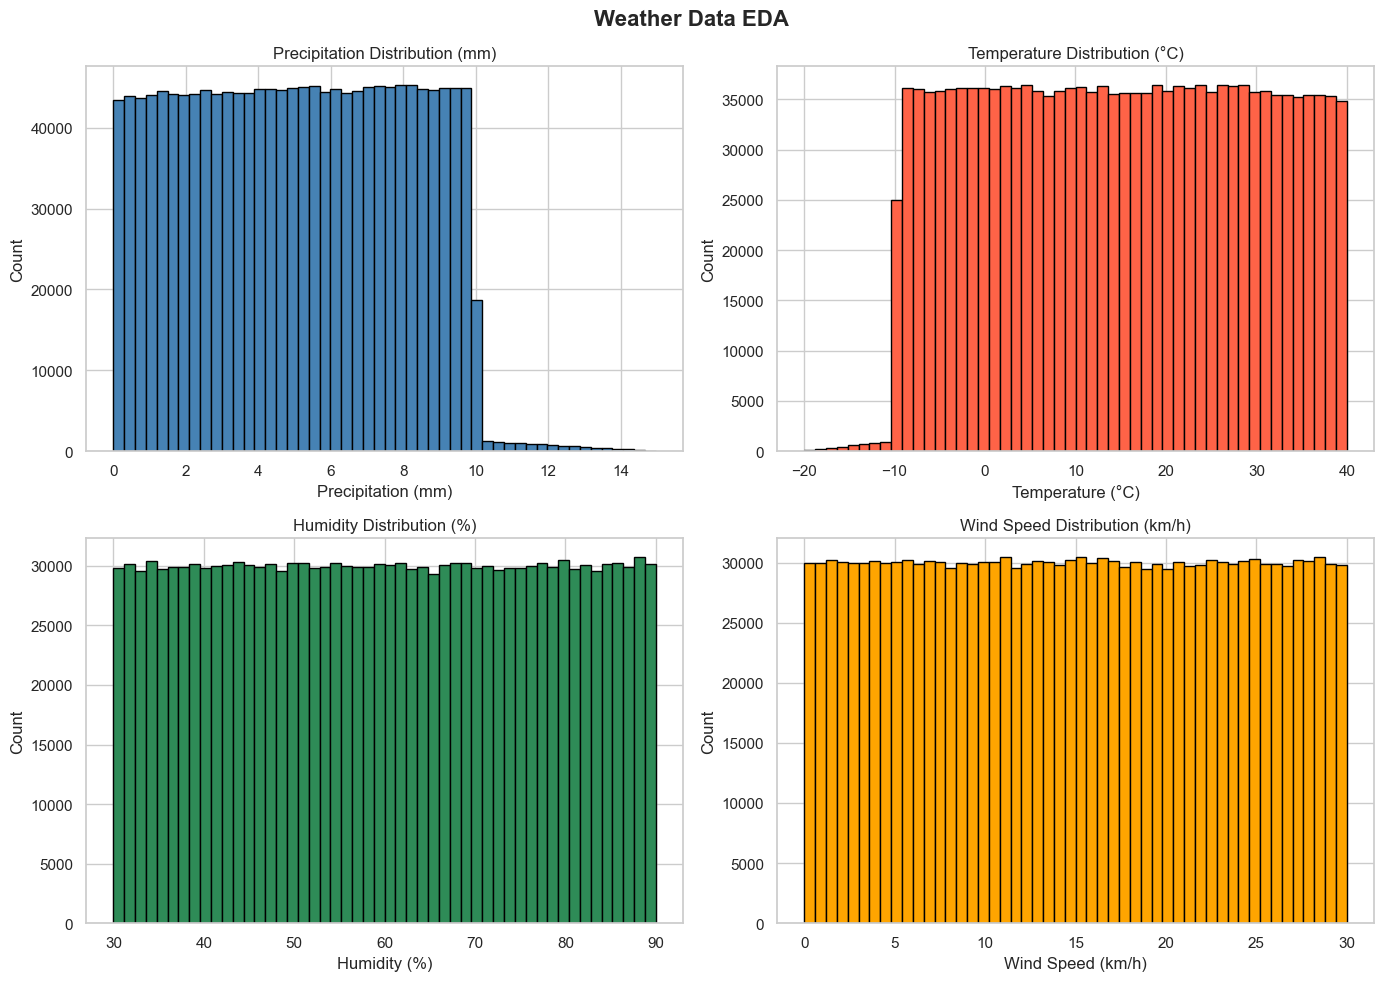

EDA saved to outputs/reports/eda_weather.png


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weather Data EDA', fontsize=16, fontweight='bold')

# 1 - Precipitation distribution
axes[0,0].hist(weather['precipitation'], bins=50, color='steelblue', edgecolor='black')
axes[0,0].set_title('Precipitation Distribution (mm)')
axes[0,0].set_xlabel('Precipitation (mm)')
axes[0,0].set_ylabel('Count')

# 2 - Temperature distribution
axes[0,1].hist(weather['temperature_c'], bins=50, color='tomato', edgecolor='black')
axes[0,1].set_title('Temperature Distribution (°C)')
axes[0,1].set_xlabel('Temperature (°C)')
axes[0,1].set_ylabel('Count')

# 3 - Humidity distribution
axes[1,0].hist(weather['humidity_pct'], bins=50, color='seagreen', edgecolor='black')
axes[1,0].set_title('Humidity Distribution (%)')
axes[1,0].set_xlabel('Humidity (%)')
axes[1,0].set_ylabel('Count')

# 4 - Wind Speed distribution
axes[1,1].hist(weather['wind_speed_kmh'], bins=50, color='orange', edgecolor='black')
axes[1,1].set_title('Wind Speed Distribution (km/h)')
axes[1,1].set_xlabel('Wind Speed (km/h)')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/reports/eda_weather.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA saved to outputs/reports/eda_weather.png")

In [18]:
# Aggregate to hourly level by (iata, date, hour)
# Uses the actual columns available: precipitation, temperature_c, humidity_pct, wind_speed_kmh
weather_hourly = weather.groupby(["iata", "date", "hour"]).agg(
    precipitation  = ("precipitation",  "mean"),
    temperature_c  = ("temperature_c",   "mean"),
    humidity_pct   = ("humidity_pct",    "mean"),
    wind_speed_kmh = ("wind_speed_kmh",  "mean")
).reset_index()

print(f"Shape after hourly aggregation: {weather_hourly.shape}")
print(f"Columns: {list(weather_hourly.columns)}")
print(weather_hourly.head())

import os
os.makedirs("../data/processed", exist_ok=True)
weather_hourly.to_csv("../data/processed/weather_features.csv", index=False)
print("Saved to data/processed/weather_features.csv")

Shape after hourly aggregation: (49980, 7)
Columns: ['iata', 'date', 'hour', 'precipitation', 'temperature_c', 'humidity_pct', 'wind_speed_kmh']
  iata        date  hour  precipitation  temperature_c  humidity_pct  \
0  DAL  2024-01-01     0       6.250919      16.380090     61.288195   
1  DAL  2024-01-01     1       4.374396      19.629655     59.651127   
2  DAL  2024-01-01     2       3.920242      15.518188     61.101467   
3  DAL  2024-01-01     3       5.452534      19.017582     54.124088   
4  DAL  2024-01-01     4       4.757037      17.335670     66.136691   

   wind_speed_kmh  
0       16.224433  
1       14.168206  
2       16.224766  
3       14.502038  
4       14.679994  
Saved to data/processed/weather_features.csv
